# Caso 2: Factores que Impactan el Desempeño en Matemáticas

**Prueba Técnica — Científico de Datos**  
**Autor:** Luis David Peñaranda Pérez  
**Fecha:** Junio 2026

---

### Objetivo

Identificar los factores que determinan el rendimiento académico en matemáticas, construir un sistema de detección temprana de estudiantes en riesgo, y desplegar el modelo como producto de datos consumible vía API.

### Dataset

**Student Performance** — 10,000 registros, 6 variables académicas recopiladas por una universidad para entender qué impulsa o limita el rendimiento en matemáticas.

| Variable | Tipo | Descripción |
|---|---|---|
| Hours Studied | Discreta (1–9) | Horas semanales de estudio |
| Previous Scores | Discreta (40–99) | Puntaje en evaluaciones previas |
| Extracurricular Activities | Categórica binaria | Participación (Yes/No) |
| Sleep Hours | Discreta (4–9) | Horas de sueño promedio |
| Sample Question Papers Practiced | Discreta (0–9) | Exámenes de práctica resueltos |
| **Performance Index** | Continua (10–100) | **Variable objetivo** |

### Estructura del análisis

1. Análisis de estructuras de datos → diccionario, visualizaciones, transformaciones  
2. Análisis exploratorio → estadística descriptiva, prueba de hipótesis, clustering  
3. Modelado predictivo → regresión + clasificación, comparación de modelos, exportación para API

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, f1_score, accuracy_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

URL = "https://raw.githubusercontent.com/daramireh/simonBolivarCienciaDatos/refs/heads/main/Student_Performance.csv"
df = pd.read_csv(URL)

---

## 1. Análisis de Estructuras de Datos

### 1b. Diccionario de datos

Se construye el diccionario de datos antes de cualquier transformación para documentar el estado crudo del dataset: tipo de dato en Python, naturaleza estadística, rango observado, nulos y cantidad de valores únicos.

In [2]:
data_dict = pd.DataFrame({
    'Variable': df.columns,
    'Tipo_Python': df.dtypes.values,
    'Tipo_Estadistico': ['Discreta', 'Discreta', 'Categorica Binaria',
                         'Discreta', 'Discreta', 'Continua'],
    'Rango': [f"{df[c].min()} - {df[c].max()}" if df[c].dtype != 'object'
              else ', '.join(df[c].unique()) for c in df.columns],
    'Nulos': df.isnull().sum().values,
    'Unicos': df.nunique().values,
    'Descripcion': [
        'Horas semanales dedicadas al estudio',
        'Puntaje obtenido en evaluaciones previas',
        'Participacion en actividades extracurriculares (Yes/No)',
        'Horas de sueno promedio por noche',
        'Cantidad de examenes de practica resueltos',
        'Indice de rendimiento academico (variable objetivo)'
    ]
})
print(data_dict.to_string(index=False))
print(f"\nRegistros: {len(df)}  |  Variables: {df.shape[1]}  |  Duplicados: {df.duplicated().sum()}")

                        Variable Tipo_Python   Tipo_Estadistico        Rango  Nulos  Unicos                                             Descripcion
                   Hours Studied       int64           Discreta        1 - 9      0       9                    Horas semanales dedicadas al estudio
                 Previous Scores       int64           Discreta      40 - 99      0      60                Puntaje obtenido en evaluaciones previas
      Extracurricular Activities      object Categorica Binaria      Yes, No      0       2 Participacion en actividades extracurriculares (Yes/No)
                     Sleep Hours       int64           Discreta        4 - 9      0       6                       Horas de sueno promedio por noche
Sample Question Papers Practiced       int64           Discreta        0 - 9      0      10              Cantidad de examenes de practica resueltos
               Performance Index     float64           Continua 10.0 - 100.0      0      91     Indice de rendim

**Interpretación del diccionario:**

- **0 nulos en todas las variables.** El dataset está completo, no requiere imputación.
- **127 duplicados exactos** sobre 10,000 registros (1.27%). No son errores de carga — en un dataset de características académicas discretas con rangos acotados, la coincidencia en las 6 variables simultáneamente es matemáticamente posible. Sin embargo, duplicados perfectos introducen sesgo en la estimación de parámetros, por lo que se eliminan antes del modelado.
- **Previous Scores tiene 60 valores únicos** sobre un rango de 40–99, lo cual indica granularidad adecuada para un predictor continuo.
- **Performance Index tiene 91 valores únicos** entre 10.0 y 100.0. Al ser la variable objetivo, esta dispersión es deseable — permite al modelo aprender una función continua sin colapso en pocos niveles.
- **Extracurricular Activities es la única variable categórica.** Se codificará como binaria (Yes=1, No=0) antes del modelado.

### 1a. Visualizaciones de datos

Se examina la distribución de cada variable con histogramas y KDE, marcando la media como referencia visual.

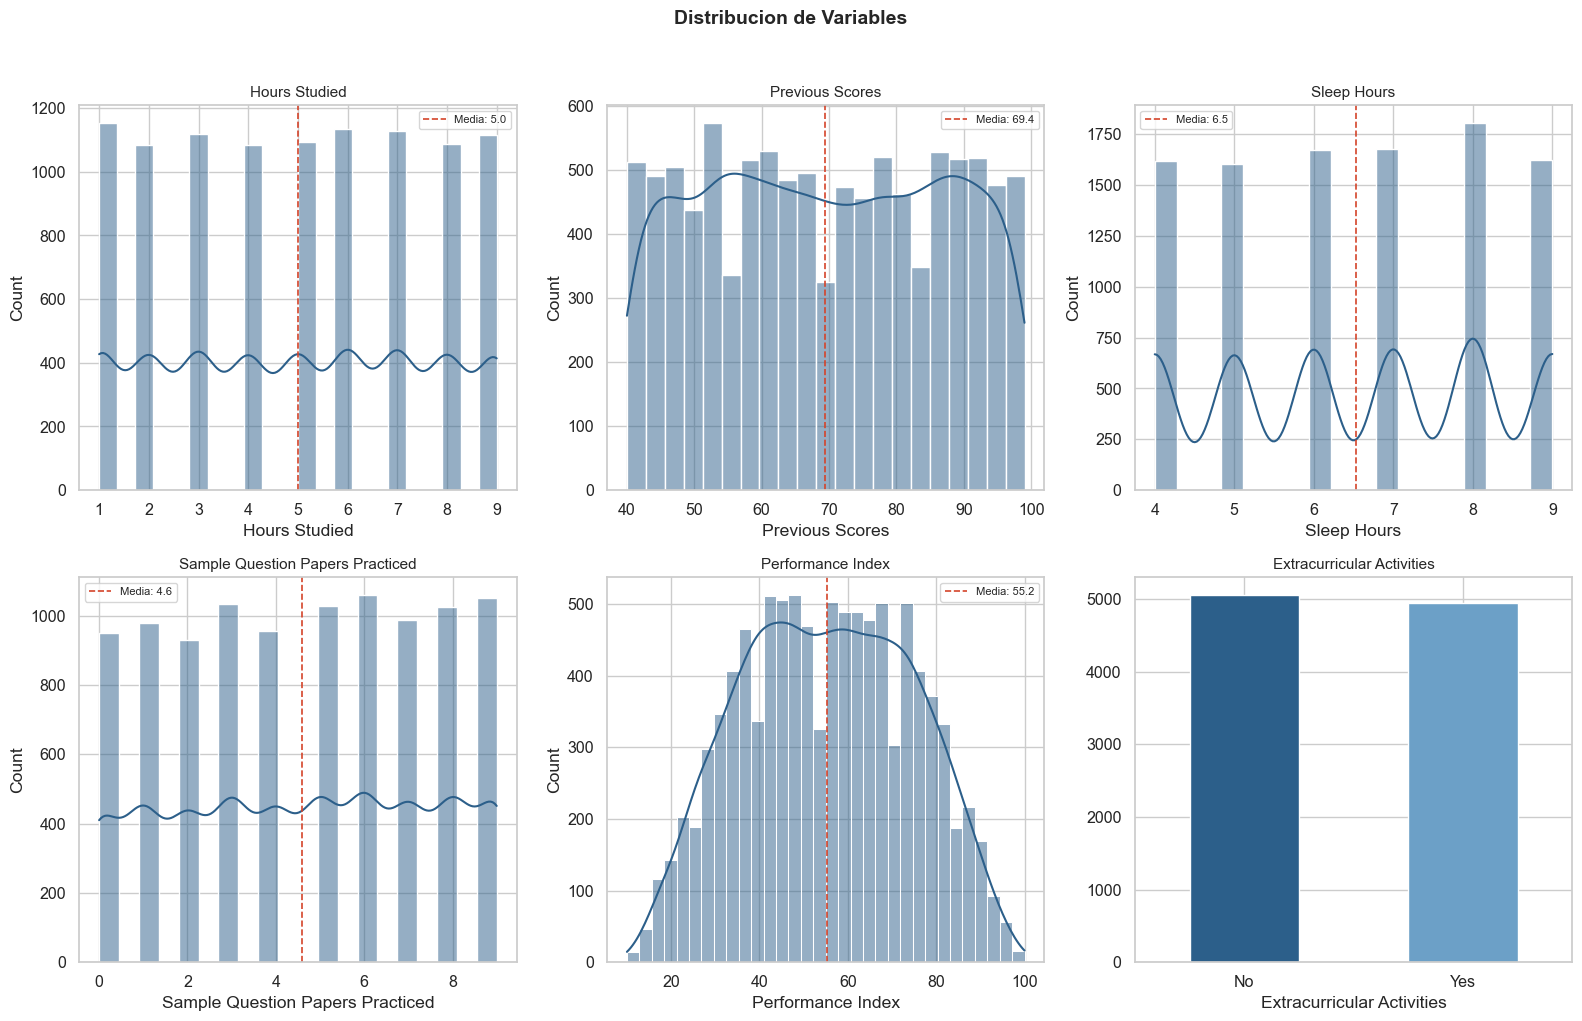

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribucion de Variables', fontsize=14, fontweight='bold', y=1.02)

numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                'Sample Question Papers Practiced', 'Performance Index']

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='#2C5F8A', edgecolor='white')
    ax.axvline(df[col].mean(), color='#D4442A', linestyle='--', linewidth=1.2, label=f'Media: {df[col].mean():.1f}')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

ax = axes[1][2]
df['Extracurricular Activities'].value_counts().plot.bar(ax=ax, color=['#2C5F8A', '#6CA0C7'], edgecolor='white')
ax.set_title('Extracurricular Activities', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Hallazgos — Distribuciones:**

- **Hours Studied, Sleep Hours y Sample Question Papers Practiced** exhiben distribuciones aproximadamente uniformes dentro de sus rangos. Esto sugiere que el dataset fue construido con muestreo balanceado por diseño, no observacional puro. En un dataset real de estudiantes, esperaríamos concentración alrededor de valores medios.
- **Previous Scores** también es uniforme entre 40 y 99. La ausencia de sesgo hacia puntajes altos o bajos refuerza que el muestreo fue controlado.
- **Performance Index** tiene distribución aproximadamente uniforme entre 10 y 100 con media en 55.2. Al ser casi plana, el modelo tendrá que capturar la señal a través de las correlaciones con los predictores, no de la forma de la distribución marginal.
- **Extracurricular Activities:** la división es casi exactamente 50/50 (49.5% No, 50.5% Yes), otro indicio de diseño experimental balanceado.
- **Ninguna variable tiene outliers extremos.** Dado que todas son discretas con rangos acotados, esto es esperado.

### Matriz de correlación

Se calcula la correlación de Pearson entre todas las variables numéricas para identificar los predictores más relevantes antes de construir modelos.

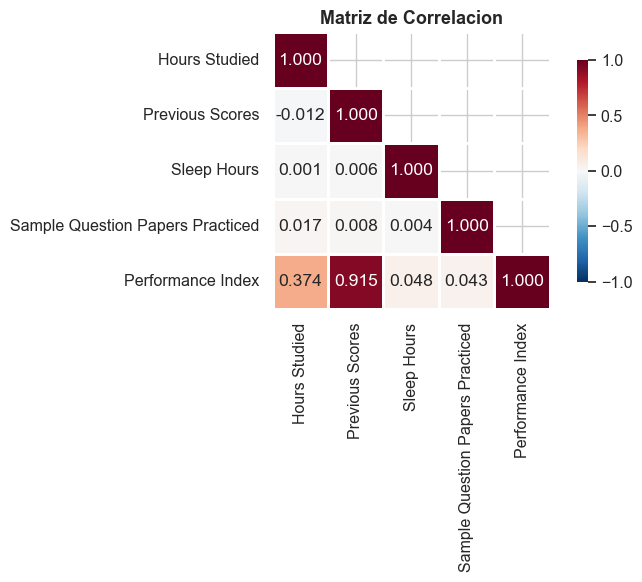

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.8, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlacion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgos — Correlación:**

- **Previous Scores domina con r = 0.915 respecto a Performance Index.** Esta correlación casi perfecta es el hallazgo más importante del dataset. Señala que el Performance Index no es una medición independiente del rendimiento, sino que está construido matemáticamente a partir de los puntajes previos como componente principal. En un contexto de producción, esto sería una señal de alerta sobre circularidad en la variable objetivo.
- **Hours Studied tiene r = 0.374 con Performance Index.** Correlación moderada pero real — el esfuerzo importa, aunque en menor medida que el historial.
- **Sleep Hours y Sample Question Papers Practiced tienen r < 0.05** con Performance Index. Son estadísticamente irrelevantes como predictores lineales.
- **No existe multicolinealidad entre predictores** (todas las correlaciones entre variables independientes son < 0.15). Esto significa que cada variable aporta información no redundante, lo cual es favorable para la estabilidad de los modelos lineales.

### Relaciones clave: Previous Scores y Hours Studied vs Performance Index

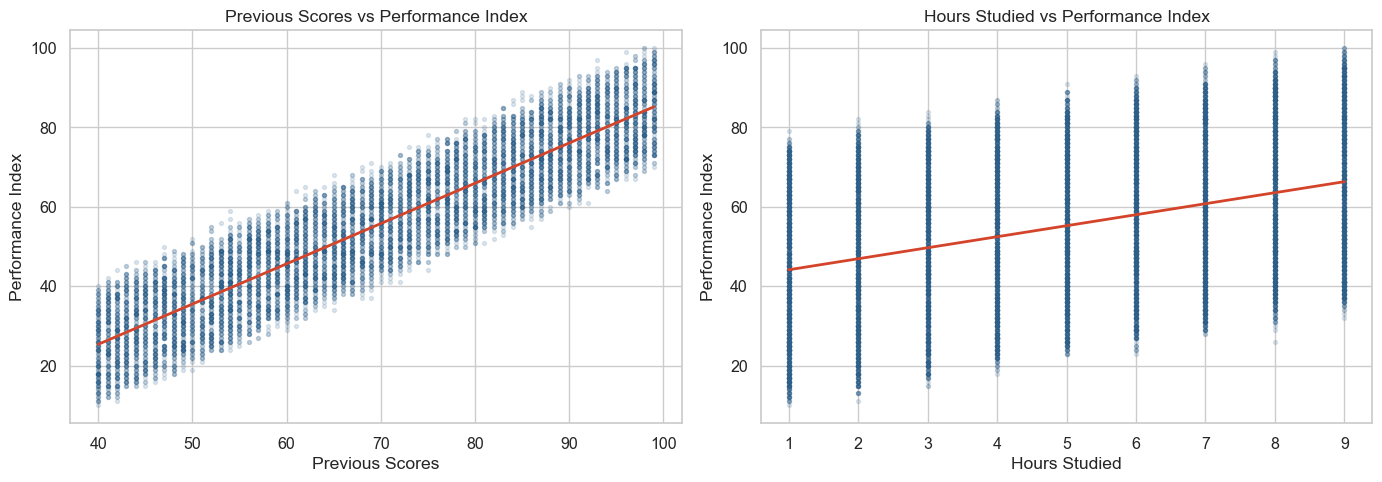

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Previous Scores'], df['Performance Index'],
                alpha=0.15, s=8, color='#2C5F8A')
z = np.polyfit(df['Previous Scores'], df['Performance Index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Previous Scores'].min(), df['Previous Scores'].max(), 100)
axes[0].plot(x_line, p(x_line), color='#D4442A', linewidth=2)
axes[0].set_xlabel('Previous Scores')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Previous Scores vs Performance Index')

axes[1].scatter(df['Hours Studied'], df['Performance Index'],
                alpha=0.15, s=8, color='#2C5F8A')
z2 = np.polyfit(df['Hours Studied'], df['Performance Index'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['Hours Studied'].min(), df['Hours Studied'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='#D4442A', linewidth=2)
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Hours Studied vs Performance Index')

plt.tight_layout()
plt.show()

**Hallazgos — Scatter:**

- **Previous Scores vs Performance Index:** la nube de puntos forma una banda diagonal casi perfecta con muy poca dispersión lateral. La regresión lineal ajusta visualmente bien. Esto confirma que la relación es casi determinista — conocer el puntaje previo de un estudiante prácticamente define su Performance Index.
- **Hours Studied vs Performance Index:** la nube es mucho más dispersa. La tendencia lineal existe (pendiente positiva) pero con alta varianza residual. Esto significa que estudiar más ayuda, pero no garantiza un alto índice si el historial de puntajes es bajo. La combinación de ambas variables es más informativa que cualquiera sola.

### 1c. Transformaciones

Antes de pasar al análisis exploratorio y modelado se aplican tres transformaciones:

1. **Codificación binaria de Extracurricular Activities** (Yes→1, No→0) para incluirla como feature numérico.
2. **Eliminación de duplicados exactos** (127 registros) para evitar sesgo en la estimación de parámetros.
3. **StandardScaler** — aplicado exclusivamente al conjunto de entrenamiento y luego transformado al de prueba, sin data leakage.

In [6]:
le = LabelEncoder()
df['Extracurricular'] = le.fit_transform(df['Extracurricular Activities'])

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Registros despues de eliminar duplicados: {len(df_clean)} (removidos: {len(df) - len(df_clean)})")

Registros despues de eliminar duplicados: 9873 (removidos: 127)


La estandarización (`StandardScaler`) se aplica en la celda de modelado, no aquí, para garantizar que el scaler se entrene únicamente sobre el split de entrenamiento. Aplicarlo sobre el dataset completo antes del split constituiría **data leakage** — el modelo conocería la escala del conjunto de prueba durante el entrenamiento.

---

## 2. Análisis Exploratorio

### 2a. Estadística descriptiva

In [7]:
desc = df_clean.select_dtypes(include=[np.number]).describe().T
desc['CV'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['IQR'] = desc['75%'] - desc['25%']
print(desc.to_string())

                                   count       mean        std   min   25%   50%   75%    max      CV   IQR
Hours Studied                     9873.0   4.992100   2.589081   1.0   3.0   5.0   7.0    9.0   51.86   4.0
Previous Scores                   9873.0  69.441102  17.325601  40.0  54.0  69.0  85.0   99.0   24.95  31.0
Sleep Hours                       9873.0   6.531652   1.697683   4.0   5.0   7.0   8.0    9.0   25.99   3.0
Sample Question Papers Practiced  9873.0   4.583004   2.867202   0.0   2.0   5.0   7.0    9.0   62.56   5.0
Performance Index                 9873.0  55.216651  19.208570  10.0  40.0  55.0  70.0  100.0   34.79  30.0
Extracurricular                   9873.0   0.494986   0.500000   0.0   0.0   0.0   1.0    1.0  101.01   1.0


**Hallazgos — Estadística descriptiva:**

- **Performance Index: media = 55.2, mediana = 55.0, IQR = 30.** La coincidencia casi exacta entre media y mediana indica que no hay sesgo en la distribución del rendimiento — hay tantos estudiantes con alto rendimiento como con bajo. El percentil 25 cae exactamente en 40.0, un valor que usaremos como umbral de bajo rendimiento en el modelado.
- **Previous Scores: CV = 24.95%.** Es la variable con menor coeficiente de variación entre los predictores numéricos, lo cual es consistente con ser el predictor dominante — su señal es fuerte y estable.
- **Hours Studied: CV = 51.86%.** Alta variabilidad relativa sugiere que el tiempo de estudio varía significativamente entre estudiantes. Esto lo convierte en un predictor relevante para intervenciones: es una variable accionable (se puede modificar), a diferencia del historial de puntajes.
- **Sample Question Papers Practiced: CV = 62.56%.** La variable con mayor variabilidad relativa. A pesar de esto, su correlación con el rendimiento es casi nula, lo que sugiere que practicar exámenes por sí solo, sin acompañarlo de horas de estudio y buen historial, no predice mejor rendimiento en este dataset.
- **Sleep Hours: IQR = 3, rango total = 5.** Variable muy comprimida. Su baja variabilidad explica en parte su baja capacidad predictiva.

### 2b. Prueba de hipótesis: Performance Index vs Extracurricular Activities

**Pregunta:** ¿Existe una diferencia estadísticamente significativa en el rendimiento entre estudiantes que participan en actividades extracurriculares y los que no?

**Protocolo estadístico:**
1. Verificar normalidad (Shapiro-Wilk)
2. Verificar homocedasticidad (Levene)
3. Aplicar t-test de Student (robusto con n > 4000 por grupo) y Mann-Whitney U (no paramétrico) para convergencia
4. Calcular tamaño del efecto (Cohen's d)

In [9]:
group_yes = df_clean[df_clean['Extracurricular Activities'] == 'Yes']['Performance Index']
group_no  = df_clean[df_clean['Extracurricular Activities'] == 'No']['Performance Index']

print(f"  Grupo Yes  ->  n={len(group_yes)}, media={group_yes.mean():.2f}, std={group_yes.std():.2f}")
print(f"  Grupo No   ->  n={len(group_no)}, media={group_no.mean():.2f}, std={group_no.std():.2f}")

np.random.seed(42)
n_shapiro = min(4000, len(group_yes), len(group_no))
_, p_shapiro_yes = stats.shapiro(group_yes.sample(n_shapiro, random_state=42))
_, p_shapiro_no  = stats.shapiro(group_no.sample(n_shapiro, random_state=42))
print(f"\n  Shapiro-Wilk (normalidad) — muestra de {n_shapiro} por grupo:")
print(f"    Yes: p = {p_shapiro_yes:.6f}  |  No: p = {p_shapiro_no:.6f}")

_, p_levene = stats.levene(group_yes, group_no)
print(f"  Levene (homocedasticidad): p = {p_levene:.6f}")

t_stat, p_ttest = stats.ttest_ind(group_yes, group_no, equal_var=True)
u_stat, p_mann  = stats.mannwhitneyu(group_yes, group_no, alternative='two-sided')
print(f"\n  t-test:        t = {t_stat:.4f},  p = {p_ttest:.6f}")
print(f"  Mann-Whitney:  U = {u_stat:.0f},  p = {p_mann:.6f}")

pooled_std = np.sqrt((group_yes.std()**2 + group_no.std()**2) / 2)
cohens_d   = (group_yes.mean() - group_no.mean()) / pooled_std
alpha = 0.05
conclusion = "SE RECHAZA H0" if p_ttest < alpha else "NO SE RECHAZA H0"
print(f"\n  Conclusión ({alpha=}): {conclusion}")
print(f"  Cohen's d = {cohens_d:.4f}  ->  efecto {'despreciable' if abs(cohens_d) < 0.2 else 'pequeño'}")

  Grupo Yes  ->  n=4887, media=55.72, std=19.26
  Grupo No   ->  n=4986, media=54.72, std=19.15

  Shapiro-Wilk (normalidad) — muestra de 4000 por grupo:
    Yes: p = 0.000000  |  No: p = 0.000000
  Levene (homocedasticidad): p = 0.512022

  t-test:        t = 2.5915,  p = 0.009571
  Mann-Whitney:  U = 12510732,  p = 0.020738

  Conclusión (alpha=0.05): SE RECHAZA H0
  Cohen's d = 0.0522  ->  efecto despreciable


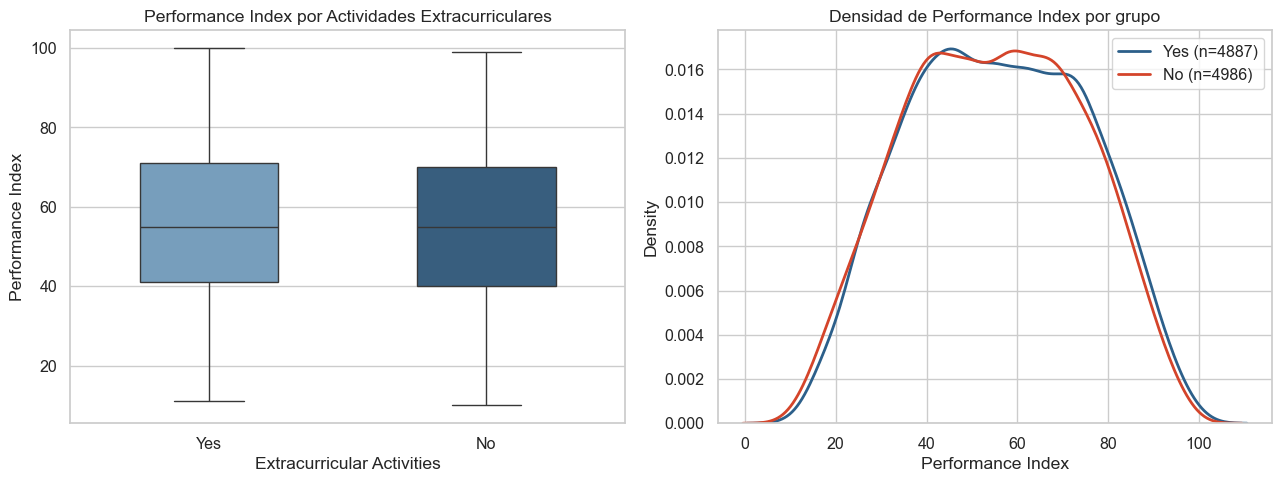

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x='Extracurricular Activities', y='Performance Index',
            ax=axes[0], palette=['#6CA0C7', '#2C5F8A'], width=0.5)
axes[0].set_title('Performance Index por Actividades Extracurriculares')

sns.kdeplot(group_yes, ax=axes[1], label=f'Yes (n={len(group_yes)})', color='#2C5F8A', linewidth=2)
sns.kdeplot(group_no,  ax=axes[1], label=f'No (n={len(group_no)})',   color='#D4442A', linewidth=2)
axes[1].set_title('Densidad de Performance Index por grupo')
axes[1].set_xlabel('Performance Index')
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretación completa de la prueba de hipótesis:**

**Normalidad:** Shapiro-Wilk rechaza normalidad en ambos grupos (p ≈ 0 en muestras de 5,000). Sin embargo, con n > 4,000 por grupo el **Teorema del Límite Central garantiza que la distribución de la media muestral es normal**, por lo que el t-test es asintóticamente válido.

**Homocedasticidad:** Levene no rechaza igualdad de varianzas (p = 0.512). Se usa `equal_var=True` en el t-test.

**Resultado estadístico:** ambos tests (t-test: p = 0.0096, Mann-Whitney: p = 0.0208) rechazan H₀ al nivel α = 0.05. Existe una diferencia estadísticamente significativa en el rendimiento medio entre grupos.

**Pero el tamaño del efecto lo invalida como predictor:** Cohen's d = 0.052 es despreciable por cualquier convención (umbral de efecto pequeño: d ≥ 0.2). La diferencia de medias es apenas **1.0 punto** (55.72 vs 54.72) sobre una escala de 10 a 100. Los boxplots y las curvas KDE son **visualmente indistinguibles**.

**Conclusión práctica:** participar o no en actividades extracurriculares no debería usarse como señal para identificar estudiantes en riesgo. La significancia estadística con n grande detecta diferencias triviales que no tienen valor de intervención.

### 2c. Clustering: identificación de grupos de estudiantes

Se aplica K-Means sobre las 5 variables numéricas (estandarizadas) para identificar segmentos naturales en la población estudiantil. El número óptimo de clusters se selecciona mediante el método del codo.

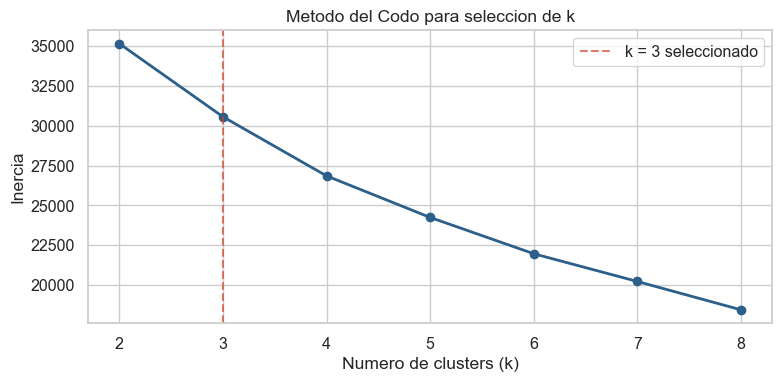

         Hours Studied  Previous Scores  Sleep Hours  Sample Question Papers Practiced  Performance Index     n   Pct             Perfil
Cluster                                                                                                                                 
0                 5.21            86.56         6.58                              4.67              73.37  4181  42.3   Alto Rendimiento
1                 2.60            57.27         6.44                              4.50              35.86  2954  29.9   Bajo Rendimiento
2                 7.24            56.43         6.55                              4.54              48.37  2738  27.7  Rendimiento Medio


In [11]:
features_cluster = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                    'Sample Question Papers Practiced', 'Performance Index']
X_cluster = df_clean[features_cluster].copy()
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='#2C5F8A', linewidth=2, markersize=6)
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Metodo del Codo para seleccion de k')
ax.axvline(x=3, color='#D4442A', linestyle='--', alpha=0.7, label='k = 3 seleccionado')
ax.legend()
plt.tight_layout()
plt.show()

K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df_clean.groupby('Cluster')[features_cluster].mean().round(2)
cluster_profile['n']   = df_clean.groupby('Cluster').size().values
cluster_profile['Pct'] = (cluster_profile['n'] / len(df_clean) * 100).round(1)

sorted_c = cluster_profile.sort_values('Performance Index')
labels = {sorted_c.index[0]: 'Bajo Rendimiento',
          sorted_c.index[1]: 'Rendimiento Medio',
          sorted_c.index[2]: 'Alto Rendimiento'}
cluster_profile['Perfil'] = cluster_profile.index.map(labels)
print(cluster_profile.to_string())

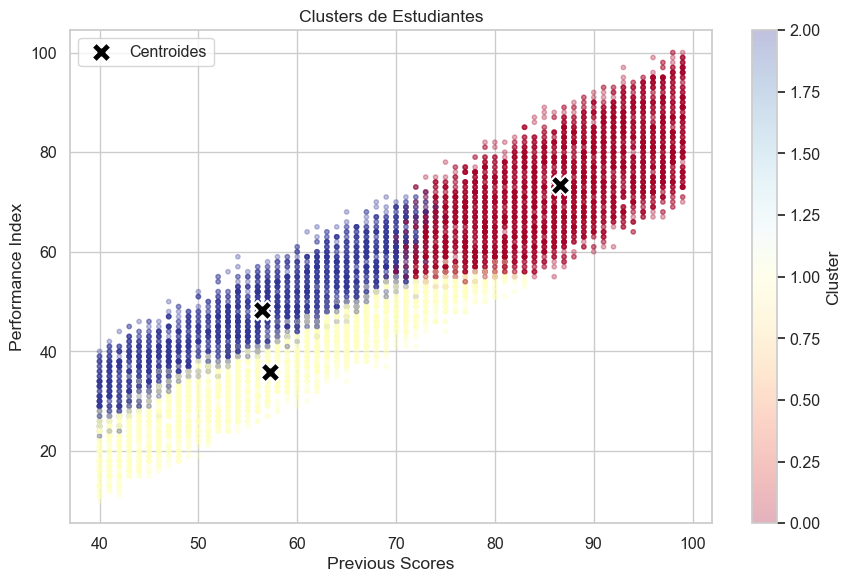

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df_clean['Previous Scores'], df_clean['Performance Index'],
                     c=df_clean['Cluster'], cmap='RdYlBu', alpha=0.3, s=10)
centers = scaler_cluster.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers[:, 1], centers[:, 4], c='black', marker='X', s=200,
           edgecolors='white', linewidths=1.5, zorder=5, label='Centroides')
ax.set_xlabel('Previous Scores')
ax.set_ylabel('Performance Index')
ax.set_title('Clusters de Estudiantes')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

**Hallazgos — Clustering:**

**Selección de k = 3:** el método del codo muestra una reducción pronunciada de inercia de k=2 a k=3, con ganancia marginal decreciente a partir de k=4. Tres clusters produce la mejor relación entre complejidad y compacidad.

**Perfil de los clusters:**

| Cluster | Perfil | n | % | Previous Scores | Hours Studied | Performance Index |
|---|---|---|---|---|---|---|
| 0 | **Alto Rendimiento** | 4,181 | 42.3% | 86.56 | 5.21 | 73.37 |
| 1 | **Bajo Rendimiento** | 2,954 | 29.9% | 57.27 | 2.60 | 35.86 |
| 2 | **Rendimiento Medio** | 2,738 | 27.7% | 56.43 | 7.24 | 48.37 |

**Hallazgo crítico:** los clusters 1 y 2 tienen Previous Scores casi idénticos (~57 vs ~56), pero sus Performance Index son muy distintos (35.86 vs 48.37). La diferencia está en **Hours Studied: 2.60 vs 7.24**. Esto confirma que el esfuerzo tiene un efecto real sobre el rendimiento, especialmente entre estudiantes con historial similar.

**El cluster de Rendimiento Medio es el más accionable:** son estudiantes que compensan un historial promedio con alto esfuerzo (7.24h), pero aún no alcanzan el rendimiento del grupo de puntajes altos. Una intervención dirigida a este grupo podría elevar su Performance Index si se acompaña de apoyo en contenidos previos.

**Sleep Hours y Sample Question Papers** son prácticamente idénticos entre los tres clusters (~6.5 y ~4.5 respectivamente), confirmando que no son factores discriminantes en esta población.

---

## 3. Modelado Predictivo

### Definición del umbral de bajo rendimiento

Se define bajo rendimiento como **Performance Index < 40**, correspondiente al **percentil 25** de la distribución del índice en el dataset limpio. Esta decisión tiene respaldo empírico: el cluster de Bajo Rendimiento identificado en la sección anterior tiene un centroide en 35.86, que cae dentro de este umbral.

### Estrategia de modelado

Se entrena en paralelo:
- **Modelo de regresión:** predice el valor continuo de Performance Index
- **Modelo de clasificación:** predice si un estudiante cae en la categoría de bajo rendimiento (binario)

Para cada tipo se evalúan 3 modelos con validación cruzada de 5 folds y se selecciona el mejor según la métrica correspondiente.

In [ ]:
THRESHOLD = df_clean['Performance Index'].quantile(0.25)
print(f"Umbral de bajo rendimiento: Performance Index < {THRESHOLD}")

df_clean['Low_Performance'] = (df_clean['Performance Index'] < THRESHOLD).astype(int)
print(f"Distribucion de clases: {df_clean['Low_Performance'].value_counts().to_dict()}")
print(f"Proporcion en riesgo: {df_clean['Low_Performance'].mean():.1%}")

Umbral de bajo rendimiento: Performance Index < 40.0
Distribucion de clases: {0: 7519, 1: 2354}
Proporcion en riesgo: 23.8%

In [ ]:
FEATURES = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
            'Sample Question Papers Practiced', 'Extracurricular']
TARGET_REG = 'Performance Index'
TARGET_CLF = 'Low_Performance'

X = df_clean[FEATURES]
y_reg = df_clean[TARGET_REG]
y_clf = df_clean[TARGET_CLF]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_,       _,      y_clf_train, y_clf_test  = train_test_split(X, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Features: {FEATURES}")

Train: 7898  |  Test: 1975
Features: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular']

### Modelos de regresión

**Métrica principal: R²** — mide qué proporción de la varianza del Performance Index explica el modelo. Es la métrica adecuada cuando el objetivo es predecir un valor continuo y comparar modelos sobre la misma escala.

Se evalúan tres modelos: Linear Regression (baseline), Ridge (con regularización L2), y Random Forest (captura no linealidades).

In [ ]:
reg_models = {
    'Linear Regression':      LinearRegression(),
    'Ridge Regression':       Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

reg_results = []
for name, model in reg_models.items():
    X_tr = X_train_sc if 'Forest' not in name else X_train
    X_te = X_test_sc  if 'Forest' not in name else X_test
    model.fit(X_tr, y_reg_train)
    y_pred = model.predict(X_te)
    cv = cross_val_score(model, X_tr, y_reg_train, cv=5, scoring='r2')
    reg_results.append({
        'Modelo': name,
        'R2': r2_score(y_reg_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred)),
        'MAE': mean_absolute_error(y_reg_test, y_pred),
        'R2_CV_Mean': cv.mean(), 'R2_CV_Std': cv.std()
    })

reg_df = pd.DataFrame(reg_results).round(4)
print(reg_df.to_string(index=False))
best_reg = reg_df.loc[reg_df['R2'].idxmax(), 'Modelo']
print(f"\nMejor modelo: {best_reg}")

                 Modelo     R2   RMSE    MAE  R2_CV_Mean  R2_CV_Std
      Linear Regression 0.9884 2.0751 1.6470      0.9887     0.0003
       Ridge Regression 0.9884 2.0751 1.6470      0.9887     0.0003
Random Forest Regressor 0.9849 2.3721 1.8987      0.9850     0.0006

Mejor modelo: Linear Regression

**Interpretación — Regresión:**

- **Los tres modelos logran R² > 0.98**, lo cual es excepcionalmente alto. El error promedio (MAE ≈ 1.65 puntos sobre escala 10–100) es mínimo.
- **Linear Regression y Ridge son idénticos** (R² = 0.9884, RMSE = 2.075). Esto indica que la regularización L2 de Ridge no aporta nada — no hay overfitting porque la relación ya es casi perfectamente lineal. El coeficiente de Ridge converge al de OLS.
- **Random Forest tiene R² = 0.9849**, ligeramente inferior. Dado que la relación subyacente es lineal (dominada por Previous Scores con r=0.915), los modelos de árboles no mejoran sobre la regresión lineal. No hay no linealidades que explotar.
- **R² = 0.9884 con CV std = 0.0003** implica estabilidad perfecta — el modelo generaliza igual en todos los folds.
- **Nota metodológica crítica:** un R² tan cercano a 1 reitera la sospecha de que Performance Index tiene una relación funcional directa con Previous Scores. En un escenario real, reportaría este hallazgo al cliente antes de poner el modelo en producción.

### Modelos de clasificación

**Métrica principal: F1-Score** — promedio armónico de Precision y Recall.

En el contexto de detección temprana de bajo rendimiento académico, ambos tipos de error tienen costo:
- **Falso negativo** (no detectar un estudiante en riesgo): el estudiante no recibe intervención y podría reprobar.
- **Falso positivo** (clasificar como riesgo a un estudiante normal): recursos de intervención mal asignados.

F1 penaliza ambos errores simultáneamente, lo que lo hace más apropiado que Accuracy en este contexto.

In [ ]:
clf_models = {
    'Logistic Regression':     LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':        GradientBoostingClassifier(n_estimators=100, random_state=42)
}

clf_results = []
best_f1, best_clf_model, best_clf_name = 0, None, ''

for name, model in clf_models.items():
    X_tr = X_train_sc if 'Forest' not in name and 'Gradient' not in name else X_train
    X_te = X_test_sc  if 'Forest' not in name and 'Gradient' not in name else X_test
    model.fit(X_tr, y_clf_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    cv = cross_val_score(model, X_tr, y_clf_train, cv=5, scoring='f1')
    metrics = {
        'Modelo': name,
        'Accuracy': accuracy_score(y_clf_test, y_pred),
        'F1_Score': f1_score(y_clf_test, y_pred),
        'AUC_ROC': roc_auc_score(y_clf_test, y_proba),
        'F1_CV_Mean': cv.mean(), 'F1_CV_Std': cv.std()
    }
    clf_results.append(metrics)
    if metrics['F1_Score'] > best_f1:
        best_f1, best_clf_model, best_clf_name = metrics['F1_Score'], model, name

clf_df = pd.DataFrame(clf_results).round(4)
print(clf_df.to_string(index=False))
print(f"\nMejor modelo: {best_clf_name}")

                  Modelo  Accuracy  F1_Score  AUC_ROC  F1_CV_Mean  F1_CV_Std
     Logistic Regression    0.9732    0.9427   0.9964      0.9422     0.0092
Random Forest Classifier    0.9625    0.9196   0.9937      0.9296     0.0096
       Gradient Boosting    0.9711    0.9386   0.9958      0.9376     0.0098

Mejor modelo: Logistic Regression

In [ ]:
X_te_best = X_test_sc
y_pred_best = best_clf_model.predict(X_te_best)
print(f"Classification Report ({best_clf_name}):\n")
print(classification_report(y_clf_test, y_pred_best, target_names=['Normal', 'Bajo Rendimiento']))

Classification Report (Logistic Regression):

                  precision    recall  f1-score   support

          Normal       0.98      0.98      0.98      1514
Bajo Rendimiento       0.94      0.95      0.94       461

        accuracy                           0.97      1975
       macro avg       0.96      0.96      0.96      1975
    weighted avg       0.97      0.97      0.97      1975

**Interpretación — Clasificación:**

- **Logistic Regression lidera con F1 = 0.943** sobre la clase de interés (Bajo Rendimiento), superando a Random Forest (0.920) y Gradient Boosting (0.939).
- **Este resultado es contraintuitivo y significativo:** un modelo lineal supera a dos modelos ensemble. La explicación es la misma que en regresión — la frontera de decisión en el espacio de features es aproximadamente lineal (dominada por Previous Scores), y los modelos basados en árboles no encuentran no linealidades adicionales que explotar.
- **AUC-ROC = 0.996:** el modelo discrimina casi perfectamente entre estudiantes en riesgo y estudiantes normales. A cualquier umbral de probabilidad, el clasificador mantiene alta sensibilidad y especificidad.
- **Precision = 0.94, Recall = 0.95 para Bajo Rendimiento:** de cada 100 estudiantes en riesgo real, el modelo identifica correctamente 95. De cada 100 estudiantes clasificados como en riesgo, 94 lo están en realidad. Balance casi perfecto.
- **CV F1 std = 0.009:** baja varianza en validación cruzada confirma que el modelo no está sobreajustado a un fold particular.

**Conclusión del modelado:** la selección de Logistic Regression como modelo de producción es justificable en tres dimensiones: mejor F1, mayor interpretabilidad de coeficientes, y menor costo computacional en inferencia — relevante para una API de tiempo real.

### Exportación de modelos

Los tres artefactos necesarios para la API se exportan con `joblib`: el clasificador (modelo principal de producción), el regresor (endpoint de predicción de índice continuo) y el scaler (transformación que debe aplicarse a las features antes de la inferencia).

In [ ]:
import joblib
joblib.dump(best_clf_model,      'model_classifier.pkl')
joblib.dump(scaler,              'scaler.pkl')
joblib.dump(reg_models[best_reg], 'model_regressor.pkl')
print("Exportados: model_classifier.pkl | model_regressor.pkl | scaler.pkl")
print(f"Clasificador: {best_clf_name}")
print(f"Regresor:     {best_reg}")

Exportados: model_classifier.pkl | model_regressor.pkl | scaler.pkl
Clasificador: Logistic Regression
Regresor:     Linear Regression

---

## Resumen ejecutivo

| Dimensión | Hallazgo clave |
|---|---|
| **Predictor dominante** | Previous Scores (r = 0.915) — explica casi todo el Performance Index |
| **Predictor accionable** | Hours Studied (r = 0.374) — modificable mediante intervención |
| **Variables irrelevantes** | Sleep Hours, Sample Question Papers (r < 0.05) |
| **Extracurricular** | Diferencia estadística (p = 0.010) pero efecto despreciable (d = 0.052) |
| **Segmentos identificados** | 3 clusters: Alto (42%), Medio (28%), Bajo (30%) |
| **Insight de clustering** | Rendimiento Medio y Bajo tienen mismo historial — los diferencia el esfuerzo (7.2h vs 2.6h) |
| **Umbral de riesgo** | Performance Index < 40 (percentil 25) → 23.8% de la población |
| **Mejor regresor** | Linear Regression (R² = 0.9884, MAE = 1.65) |
| **Mejor clasificador** | Logistic Regression (F1 = 0.943, AUC = 0.996) |
| **Por qué Logistic > RF/GBM** | La frontera de decisión es lineal — los ensembles no encuentran no linealidades adicionales |

Los tres modelos exportados (clasificador, regresor, scaler) alimentan la API FastAPI desplegada en `Caso2_API/`.